In [1]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

I0000 00:00:1776682938.827228  239917 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776682938.827490  239917 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776682938.855976  239917 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776682939.543420  239917 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

2.21.0
[]


E0000 00:00:1776682940.415166  239917 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776682940.415650  240044 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776682940.430184  239917 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y =(iris.target == 0)

per_clf = Perceptron(random_state=42)
per_clf.fit(X,y)

X_new = [[2, 0.5],[3,1]]
y_pred = per_clf.predict(X_new)
y_pred

array([ True, False])

In [3]:
import tensorflow as tf
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full),(X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

print(X_train_full.shape)  # images: (60000, 28, 28)
print(y_train_full.shape)  # labels: (60000,)

print(X_test.shape)        # (10000, 28, 28)
print(y_test.shape)        # (10000,)

print(X_train.shape)       # (55000, 28, 28)
print(y_train.shape)       # (55000,)

print(X_valid.shape)       # (5000, 28, 28)
print(y_valid.shape)       # (5000,)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
(55000, 28, 28)
(55000,)
(5000, 28, 28)
(5000,)


In [4]:
X_train = X_train[..., tf.newaxis] / 255.0
X_valid = X_valid[..., tf.newaxis] / 255.0
X_test  = X_test[..., tf.newaxis] / 255.0

print(X_train.shape)  # (55000, 28, 28, 1)

(55000, 28, 28, 1)


In [5]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

In [6]:
# docker run --gpus all -it --rm \
#   -v ~/Desktop/controlEx_prep:/workspace \
#   -w /workspace \
#   tensorflow/tensorflow:latest-gpu \
#   bash

In [7]:
import tensorflow as tf

print(tf.config.list_physical_devices("GPU"))

# Optional: enable memory growth if you see cuDNN internal errors
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

[]


In [8]:
# Create classification MLP with sequential API
tf.random.set_seed(42)
model = tf.keras.Sequential(name="Custom_test_p320")
model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300,activation="relu"))
model.add(tf.keras.layers.Dense(100,activation="relu"))
model.add(tf.keras.layers.Dense(10,activation="softmax"))

model.summary()

Model: "Custom_test_p320"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.layers


[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

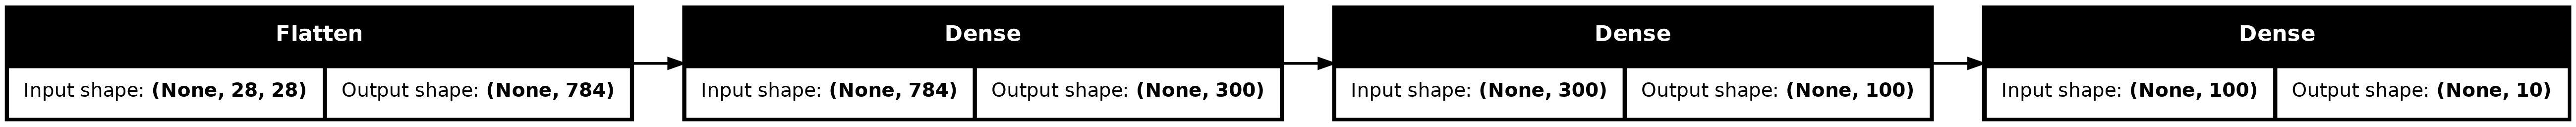

In [10]:
tf.keras.utils.plot_model(model,rankdir="LR", show_shapes=True)

In [11]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [12]:
from pathlib import Path
from time import strftime

def get_run_logdir(root_logdir="Tensorboard_logs"):
    return Path(root_logdir) / strftime("run_%Y_%m_%d_%H_%M_%S")

run_logdir = get_run_logdir()


tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir,
                                                profile_batch=(100,200))


I0000 00:00:1776682941.029355  239917 profiler_session.cc:117] Profiler session initializing.
I0000 00:00:1776682941.029371  239917 profiler_session.cc:132] Profiler session started.
I0000 00:00:1776682941.029383  239917 cupti_tracer.cc:1112] Profiler found 1 GPUs
E0000 00:00:1776682941.029401  239917 cuda_version_variants.cc:39] Failed to get CUDA runtime version, error: Error loading CUDA libraries. GPU will not be used. - Error loading CUDA libraries. GPU will not be used.
E0000 00:00:1776682941.029407  239917 cuda_version_variants.cc:55] Failed to get CUDA driver version, error: Error loading CUDA libraries. GPU will not be used. - Error loading CUDA libraries. GPU will not be used.
E0000 00:00:1776682941.029591  239917 cupti_error_manager.cc:166] cuptiGetTimestamp: error 999: 
E0000 00:00:1776682941.029599  239917 cupti_error_manager.cc:219] cuptiSubscribe: ignored due to a previous error.
E0000 00:00:1776682941.029600  239917 cupti_error_manager.cc:256] cuptiGetResultString: igno

In [13]:
history = model.fit(X_train, y_train, 
                    epochs = 30, 
                    validation_data=(X_valid, y_valid),
                    callbacks=[tensorboard_cb])

Epoch 1/30
 200/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4425 - loss: 1.7393

I0000 00:00:1776682941.567775  239917 profiler_session.cc:117] Profiler session initializing.
I0000 00:00:1776682941.567802  239917 profiler_session.cc:132] Profiler session started.
E0000 00:00:1776682941.567818  239917 cupti_error_manager.cc:164] cuptiGetTimestamp: ignored due to a previous error.
E0000 00:00:1776682941.567828  239917 cupti_error_manager.cc:219] cuptiSubscribe: ignored due to a previous error.
E0000 00:00:1776682941.567829  239917 cupti_error_manager.cc:256] cuptiGetResultString: ignored due to a previous error.
E0000 00:00:1776682941.567830  239917 cupti_tracer.cc:1383] function Subscribe(&subscriber_, (CUpti_CallbackFunc)ApiCallback, this)failed with error 
E0000 00:00:1776682941.567834  239917 profiler_controller.cc:51] INTERNAL: CUPTI call error: 
I0000 00:00:1776682941.724532  239917 profiler_session.cc:81] Profiler session collecting data.
E0000 00:00:1776682941.728155  239917 profiler_controller.cc:67] ABORTED: Previous call returned an error.
E0000 00:00:1776

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7671 - loss: 0.7048 - val_accuracy: 0.8244 - val_loss: 0.5100
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8299 - loss: 0.4883 - val_accuracy: 0.8390 - val_loss: 0.4609
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8450 - loss: 0.4440 - val_accuracy: 0.8436 - val_loss: 0.4394
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8541 - loss: 0.4165 - val_accuracy: 0.8488 - val_loss: 0.4214
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8610 - loss: 0.3960 - val_accuracy: 0.8502 - val_loss: 0.4094
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8666 - loss: 0.3797 - val_accuracy: 0.8548 - val_loss: 0.4010
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8717 - loss: 0.3659 - val_accuracy: 0.8562 - val_loss: 0.3941
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8752 - loss: 0.3538 - val_accurac

In [21]:
%load_ext tensorboard
%tensorboard --logdir=./Tensorboard_logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 247570), started 0:01:59 ago. (Use '!kill 247570' to kill it.)

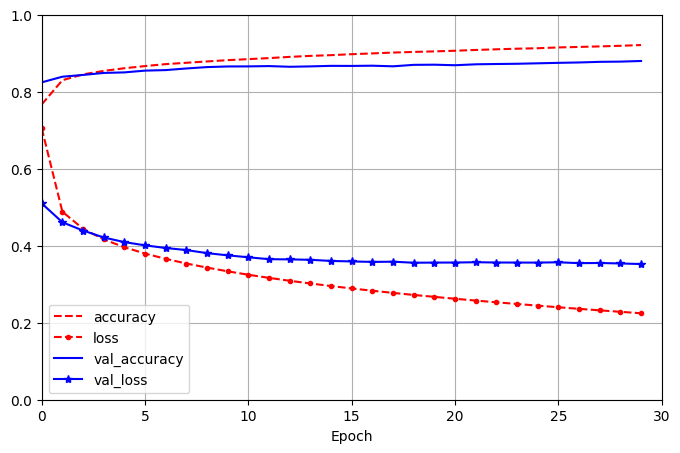

<Axes: xlabel='Epoch'>

In [14]:
from utils import plot_training_history

plot_training_history(
    history,
    figsize=(8, 5),
    xlim=(0, 30),
    ylim=(0, 1),
    style=["r--", "r--.", "b-", "b-*"]
)

In [15]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8707 - loss: 0.3754


[0.3753872215747833, 0.8707000017166138]

In [16]:
X_train.shape

(55000, 28, 28, 1)

In [17]:
model.save("custom_model.keras")

In [18]:
model = tf.keras.models.load_model("custom_model.keras")
model.predict((X_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([[1.52871553e-06, 3.76457052e-08, 2.35149173e-06, ...,
        7.80926738e-03, 2.65062845e-04, 5.19350588e-01],
       [1.31629577e-05, 1.63531944e-08, 9.96437669e-01, ...,
        1.04755198e-10, 6.31771044e-08, 2.07934892e-09],
       [7.29433532e-06, 9.99990940e-01, 1.23752756e-07, ...,
        5.03803466e-12, 2.24151830e-09, 4.45237458e-11],
       ...,
       [2.71823700e-03, 1.68399854e-08, 1.30042084e-03, ...,
        3.89078934e-07, 9.94625986e-01, 2.78052880e-07],
       [2.95232076e-06, 9.99946237e-01, 2.30733531e-06, ...,
        1.96642458e-09, 7.37235553e-08, 3.11016350e-08],
       [1.47776345e-05, 1.67183100e-06, 1.34903294e-05, ...,
        8.26945354e-04, 1.52388558e-04, 1.49756461e-05]],
      shape=(10000, 10), dtype=float32)